In [1]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit, minimize

from readrbdata import load

import matplotlib.pyplot as plt

from fittingutils import *
from readrbdata import transform

%matplotlib widget

In [2]:
spike_data = []

In [3]:
sat = load(sat=True, mag=False)
uns = load(sat=False, mag=False)

sat.signal /= 10.
uns.signal /= 10.

# this makes the two signals agree a lot more, very annoyingly...
def loss(offset):
    diff = sat.signal - np.interp(sat.frequency + offset, uns.frequency, uns.signal, left=np.nan, right=np.nan)
    diff = diff[np.isfinite(diff)]
    return np.sum(diff**2) / len(diff)

offset_opt_res = minimize(loss, 0.)
offset_opt_res

th =
[  -1.3136459    77.98584414  139.67492051 -757.41685834]
cov =
[[ 4.19715735e-06 -2.08509558e-04 -4.18071133e-03  1.35566598e-01]
 [-2.08509558e-04  1.62614088e-02 -1.03372099e-01 -3.73674413e+00]
 [-4.18071133e-03 -1.03372099e-01  2.84954512e+01 -4.74635905e+02]
 [ 1.35566598e-01 -3.73674413e+00 -4.74635905e+02  1.14397303e+04]]
param_samples.shape = (1024, 4)
model_samples.shape = (1024, 13269)
th =
[  -1.33079702   78.09080483  141.15500116 -786.81623483]
cov =
[[ 4.28781164e-06 -2.10320102e-04 -4.27857286e-03  1.37195493e-01]
 [-2.10320102e-04  1.64007640e-02 -1.14719605e-01 -3.53066428e+00]
 [-4.27857286e-03 -1.14719605e-01  2.94607246e+01 -4.88487463e+02]
 [ 1.37195493e-01 -3.53066428e+00 -4.88487463e+02  1.15834900e+04]]
param_samples.shape = (1024, 4)
model_samples.shape = (1024, 13246)


  message: Desired error not necessarily achieved due to precision loss.
  success: False
   status: 2
      fun: 0.0358322138986917
        x: [-2.527e-02]
      nit: 7
      jac: [ 6.914e-04]
 hess_inv: [[ 4.810e-05]]
     nfev: 100
     njev: 44

In [4]:
# whatever
sat.frequency += offset_opt_res.x[0]

In [5]:
diff_freq = sat.frequency

diff_signal = sat.signal - np.interp(diff_freq, uns.frequency, uns.signal, left=np.nan, right=np.nan)

ok_idx = np.isfinite(diff_signal)

diff_signal = diff_signal[ok_idx]
diff_freq = diff_freq[ok_idx]

In [6]:
sat.frequency[0], uns.frequency[0]

(-4.258866606651064, -4.306298564213494)

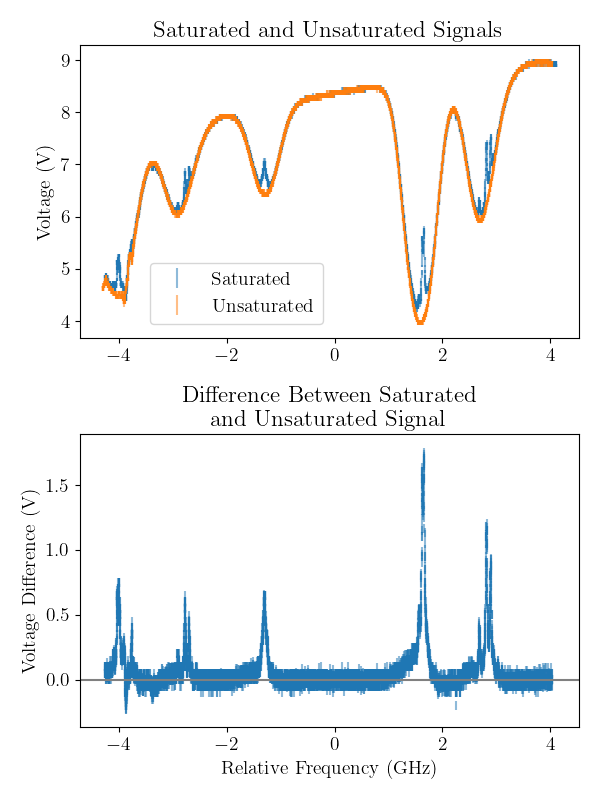

In [7]:
fig, (sig_ax, diff_ax) = plt.subplots(nrows=2, sharex=True, figsize=(6, 8))
# plt.rcParams.update({'font.size': 12})

sig_ax.set_title('Saturated and Unsaturated Signals')
sig_ax.errorbar(sat.frequency, sat.signal, yerr=0.025, alpha=0.5, label='Saturated', ls='')
sig_ax.errorbar(uns.frequency, uns.signal, yerr=0.025, alpha=0.5, label='Unsaturated', ls='')
sig_ax.set_ylabel('Voltage (V)')
# sig_ax.set_xlabel('Relative Frequency (GHz)')
sig_ax.xaxis.set_tick_params(labelbottom=True)
sig_ax.legend(loc=(0.14, 0.05))

diff_ax.set_title('Difference Between Saturated\nand Unsaturated Signal')
diff_ax.errorbar(diff_freq, diff_signal, yerr=np.sqrt(2)*0.025, alpha=0.5, ls='')
diff_ax.axhline(0., color="gray")
diff_ax.set_xlabel('Relative Frequency (GHz)')
diff_ax.set_ylabel('Voltage Difference (V)')
# diff_ax.legend()
fig.tight_layout()


Text(0.5, 77.50290995896462, 'Relative Frequency (GHz)')

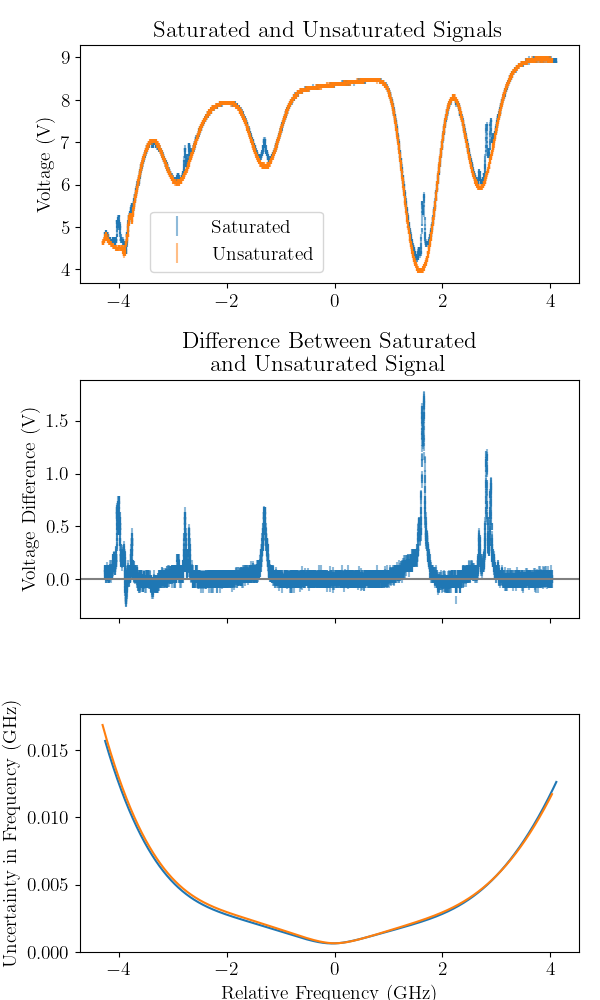

In [8]:
fig, (sig_ax, diff_ax, unc_ax) = plt.subplots(nrows=3, sharex=True, figsize=(6, 10))
# plt.rcParams.update({'font.size': 12})

sig_ax.set_title('Saturated and Unsaturated Signals')
sig_ax.errorbar(sat.frequency, sat.signal, yerr=0.025, alpha=0.5, label='Saturated', ls='')
sig_ax.errorbar(uns.frequency, uns.signal, yerr=0.025, alpha=0.5, label='Unsaturated', ls='')
sig_ax.set_ylabel('Voltage (V)')
# sig_ax.set_xlabel('Relative Frequency (GHz)')
sig_ax.xaxis.set_tick_params(labelbottom=True)
sig_ax.legend(loc=(0.14, 0.05))

diff_ax.set_title('Difference Between Saturated\nand Unsaturated Signal')
diff_ax.errorbar(diff_freq, diff_signal, yerr=np.sqrt(2)*0.025, alpha=0.5, ls='')
diff_ax.axhline(0., color="gray")
# diff_ax.set_xlabel('Relative Frequency (GHz)')
diff_ax.set_ylabel('Voltage Difference (V)')
# diff_ax.legend()
fig.tight_layout()

unc_ax.plot(sat.frequency, sat.u_frequency, label='Saturated Spectrum')
unc_ax.plot(uns.frequency, uns.u_frequency, label='Unsaturated Spectrum')

unc_ax.set_ylim(bottom = 0.)

unc_ax.set_ylabel('Uncertainty in Frequency (GHz)')
unc_ax.set_xlabel('Relative Frequency (GHz)')

# Fit Ugly One

Fitting this one all at once just because they're so close together

In [9]:
def triple_lorentzian(
        x, 
        x00, g0, a0, 
        x01, g1, a1, 
        x02, g2, a2, 
        offset, offset_slope
):
    return Lorentzian(x, x00, g0, a0, 0.) + Lorentzian(x, x01, g1, a1, 0.) + Lorentzian(x, x02, g2, a2, 0.) + offset + x*offset_slope

len(p0) = 11
fit params:
[ 1.56286338  0.01103887  0.28855464  1.62411449  0.01268926  1.1039322
  1.65535807  0.01680305  1.37116099  0.35841469 -0.12338653]
cov:
[[ 2.28448122e-07  6.52554087e-09 -6.48133302e-08 -4.00424486e-10
  -1.79899477e-08 -1.69597620e-08 -4.07637901e-09  2.84874448e-09
   3.60482822e-07  1.14975797e-06 -6.66780728e-07]
 [ 6.52554087e-09  6.25826578e-07 -5.62720109e-06 -3.20328350e-09
  -5.28024664e-08 -7.95951653e-08 -1.17080152e-08  2.20043188e-08
   1.53266125e-06 -6.51822254e-06  3.45774400e-06]
 [-6.48133302e-08 -5.62720109e-06  1.53985507e-04 -5.96442758e-08
   3.12441281e-08  6.22371965e-06  9.34279939e-09  5.40179954e-08
   3.90903993e-06 -1.25786241e-05  5.63285135e-06]
 [-4.00424486e-10 -3.20328350e-09 -5.96442758e-08  3.27800049e-08
   2.64290704e-08  8.52918209e-07  1.97885234e-08 -2.60459502e-08
  -9.37679704e-07 -5.93892251e-07  4.28265432e-07]
 [-1.79899477e-08 -5.28024664e-08  3.12441281e-08  2.64290704e-08
   9.69844626e-08 -1.58275817e-07  3.3

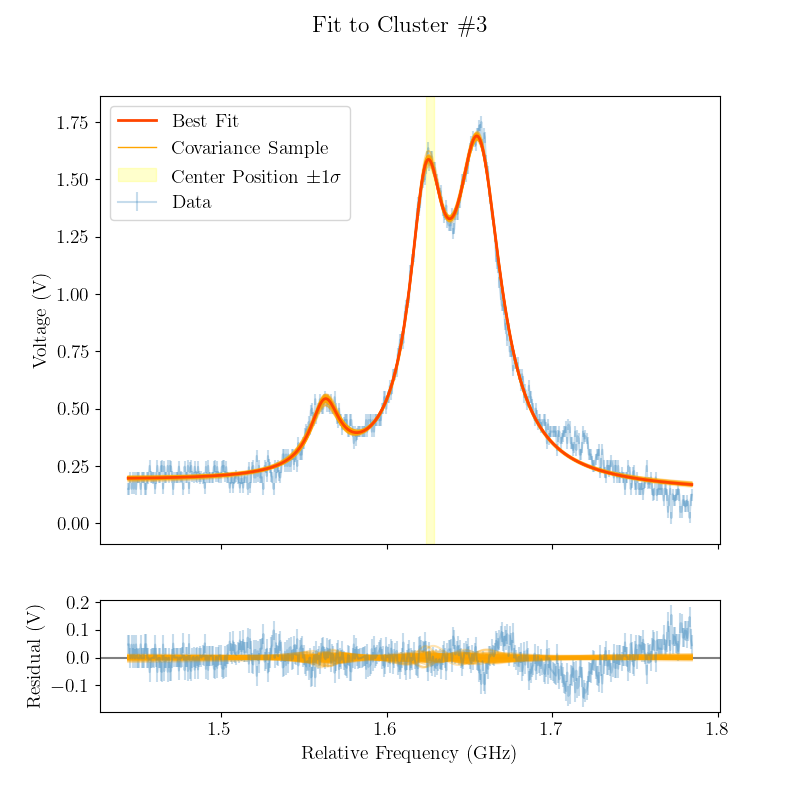

In [10]:
x_low = .034 # remnant from when i worked in time units i am too lazy to fix
x_high = .038
cluster_n = 2

# MAKE PLOTS
# fig, ((guess_data_ax, fit_data_ax), (guess_res_ax, fit_res_ax)) = plt.subplots(2, 2, sharex=True, height_ratios=[4, 1], figsize=(15, 7))
fig, (fit_data_ax, fit_res_ax) = plt.subplots(2, 1, sharex=True, height_ratios=[4, 1], figsize=(8, 8))

# ESTABLISH INITIAL GUESSES
spidx, = np.nonzero((x_low <= sat.time) & (sat.time < x_high)) # single peak indices

x = diff_freq[spidx]
y = diff_signal[spidx]

baseline_slope_guess = (y[-1] - y[0]) / (x[-1] - x[0])

# p0 = [
#     4.92546154e+00,
#     9.86185753e-03,  
#     3.04749742e+00,  
    
#     4.97997906e+00,
#     1.10517537e-02,
#     1.12703114e+01,
    
#     5.00778981e+00,
#     1.48773556e-02,
#     1.39587998e+01,
    
#     7.11786513e+01,
#     -1.40941661e+01
# ]

p0 = [
    1.56497157e+00,
    1.09529992e-02,
    2.90392085e-01,

    1.62622119e+00,
    1.27916757e-02,
    1.10165019e+00,
    
    1.65743724e+00,
    1.68264795e-02,
    1.36782465e+00,
    
    4.94723104e+00,
    -2.09194020e+00
]
print(f"{len(p0) = }")

# guess_data_ax.errorbar(x, y, yerr=np.sqrt(2)*0.25, alpha=0.25)
# guess_data_ax.plot(x, triple_lorentzian(x, *p0), zorder=10, color='blue', label='Model with First Guess')

# guess_data_ax.set_title('Fit Initial Guess')
# guess_data_ax.set_ylabel('Voltage (V)')
# guess_data_ax.legend()

# residuals = triple_lorentzian(x, *p0) - y

# guess_res_ax.axhline(0., color='gray')
# guess_res_ax.errorbar(x, residuals, yerr=np.sqrt(2)*0.25, alpha=0.25)
# guess_res_ax.set_ylabel('Residual (V)')
# # guess_res_ax.set_ylim(np.min(residuals), np.max(residuals))

fit_params, cov = curve_fit(triple_lorentzian, x, y, p0, np.sqrt(2)*0.025)
print(f"fit params:\n{fit_params}")
print(f"cov:\n{cov}")

fit_data_ax.errorbar(x, y, yerr=0.025, alpha=0.25, label='Data')
fit_data_ax.plot(x, triple_lorentzian(x, *fit_params), lw=2, c='orangered', zorder=10, label='Best Fit')
data_y_lims = fit_data_ax.set_ylim()

random_fit_samples = np.random.multivariate_normal(fit_params, cov, 64)
for fit_sample in random_fit_samples:
    fit_data_ax.plot(x, triple_lorentzian(x, *fit_sample), lw=1, c='orange', zorder=5, alpha=0.3)
fit_data_ax.plot(x, triple_lorentzian(x, *fit_sample), lw=1, c='orange', zorder=5, label='Covariance Sample')

local_uncertainty = sat.u_frequency[np.argmin(np.abs(sat.frequency - p0[3]))]
print(f"{local_uncertainty = }")
fit_data_ax.axvspan(p0[3] - local_uncertainty, p0[3] + local_uncertainty, alpha=0.2, color='yellow', label='Center Position $\\pm1\\sigma$')

fit_data_ax.legend()

fit_data_ax.set_ylim(data_y_lims)
# fit_data_ax.set_title('Resulting Fit')
fit_data_ax.set_ylabel('Voltage (V)')


residuals = triple_lorentzian(x, *fit_params) - y

fit_res_ax.axhline(0., color='gray')
fit_res_ax.errorbar(x, residuals, yerr=np.sqrt(2)*0.025, alpha=0.25)
for fit_sample in random_fit_samples:
    fit_res_ax.plot(x, triple_lorentzian(x, *fit_sample) - triple_lorentzian(x, *fit_params), c='orange', alpha=0.3)

fit_res_ax.set_ylabel('Residual (V)')
fit_res_ax.set_xlabel('Relative Frequency (GHz)')

fig.suptitle(f'Fit to Cluster \\#{cluster_n + 1}')

red_chi2 = np.sum((residuals / (np.sqrt(2)*.025))**2) / (len(residuals) - 11)
print(f"{red_chi2 = :.4g}")

for i in range(3):
    this_spike = {
        "center_freq": fit_params[0 + i*3],
        "e_center_freq": local_uncertainty, #np.sqrt(np.diag(cov))[0 + i*3],
        "amplitude": fit_params[2 + i*3],
        "cluster_id": cluster_n,
        "red_chi2": red_chi2
    }

    print(f"{this_spike = }")

    if this_spike not in spike_data:
        spike_data.append(this_spike)
    else:
        print('SPIKE NOT APPENDED, WE ALREADY GOT THIS ONE')

    print(f"{len(spike_data) = }")


plt.locator_params(nbins=5)

fig.savefig("figs/uglypeaks.png", dpi=800)


In [11]:
def red_lorentzian(x, center, gamma, amplitude, baseline, baseline_slope):
    return Lorentzian(x, center, gamma, amplitude, baseline) + baseline_slope*x

In [34]:
def fit_spike(x_low, x_high, cluster_n, spike_n=0):
    # MAKE PLOTS
    # fig, ((guess_data_ax, fit_data_ax), (guess_res_ax, fit_res_ax)) = plt.subplots(2, 2, sharex=True, height_ratios=[4, 1], figsize=(15, 7))
    fig, (fit_data_ax, fit_res_ax) = plt.subplots(2, 1, sharex=True, height_ratios=[4, 1], figsize=(8, 8))

    # ESTABLISH INITIAL GUESSES
    spidx, = np.nonzero((x_low <= sat.time) & (sat.time < x_high)) # single peak indices

    x = diff_freq[spidx]
    y = diff_signal[spidx]

    center_guess = x[np.argmax(diff_signal[spidx])]
    slope_guess = (y[-1] - y[0]) / (x[-1] - x[0])

    p0 = [
        center_guess,
        Lorentzian.guess_gamma(x, y),
        np.max(y) - (slope_guess*(center_guess - x[0]) + y[0]),
        y[0] - slope_guess*x[0],
        slope_guess
    ]
    print(f"{p0 = }")

    # guess_data_ax.errorbar(x, y, yerr=np.sqrt(2)*0.025, alpha=0.25)
    # guess_data_ax.plot(x, red_lorentzian(x, *p0), zorder=10, color='blue')

    # guess_data_ax.axvline(p0[0], label='x0 guess', c='red', alpha=0.5)
    # guess_data_ax.plot([p0[0] - p0[1], p0[0] + p0[1]], [(p0[2] + p0[3] + slope_guess*x[0])/2, (p0[2] + p0[3] + slope_guess*x[0])/2], color='green', alpha=0.5, label='FWHM guess')
    # # guess_data_ax.axhline(p0[2] + p0[3] + slope_guess*x[0], label='amplitude guess', c='red', alpha=0.5)
    # # guess_data_ax.axline(slope_guess*(center_guess - x[0]) + y[0], slope=slope_guess)
    # guess_data_ax.axhline(p0[3] + slope_guess*x[0], label='baseline guess', c='red', alpha=0.5)

    # guess_data_ax.set_title('Fit Initial Guess')
    # guess_data_ax.set_ylabel('Voltage (V)')
    # guess_data_ax.legend()

    # residuals = red_lorentzian(x, *p0) - y

    # guess_res_ax.axhline(0., color='gray')
    # guess_res_ax.errorbar(x, residuals, yerr=np.sqrt(2)*0.025, alpha=0.25)
    # guess_res_ax.set_ylabel('Residual (V)')
    # guess_res_ax.set_ylim(np.min(residuals), np.max(residuals))
    
    fit_params, cov = curve_fit(red_lorentzian, x, y, p0, np.sqrt(2)*0.025)
    converged = np.all(np.isfinite(cov))
    print(f"fit params:\n{fit_params}")
    print(f"cov:\n{cov}")

    fit_data_ax.errorbar(x, y, yerr=0.025, alpha=0.25, label='Data')
    fit_data_ax.plot(x, red_lorentzian(x, *fit_params), lw=2, c='orangered', zorder=10, label='Best Fit')
    data_y_lims = fit_data_ax.set_ylim()

    if converged:
        random_fit_samples = np.random.multivariate_normal(fit_params, cov, 64)
        for fit_sample in random_fit_samples:
            fit_data_ax.plot(x, red_lorentzian(x, *fit_sample), lw=1, c='orange', zorder=5)
        fit_data_ax.plot(x, red_lorentzian(x, *fit_sample), lw=1, c='orange', zorder=5, label='Covariance Sample')
    
    local_uncertainty = sat.u_frequency[np.argmin(np.abs(sat.frequency - p0[0]))]
    print(f"{local_uncertainty = }")
    fit_data_ax.axvspan(fit_params[0] - local_uncertainty, fit_params[0] + local_uncertainty, alpha=0.2, color='yellow', label='Center Position $\\pm 1 \\sigma$')

    fit_data_ax.set_ylabel('Voltage Difference (V)')
    fit_data_ax.legend()

    fit_data_ax.set_ylim(data_y_lims)
    # fit_data_ax.set_title('Resulting Fit')


    residuals = red_lorentzian(x, *fit_params) - y

    fit_res_ax.axhline(0., color='gray')
    fit_res_ax.errorbar(x, residuals, yerr=np.sqrt(2)*0.025, alpha=0.25)
    if converged:
        for fit_sample in random_fit_samples:
            fit_res_ax.plot(x, red_lorentzian(x, *fit_sample) - red_lorentzian(x, *fit_params), c='orange')

    fit_res_ax.set_xlabel("Relative Frequency (GHz)")
    fit_res_ax.set_ylabel("Residual (V)")

    fig.suptitle(f'Fit to Cluster \\#{cluster_n + 1}, Spike \\#{spike_n + 1}')
    
    red_chi2 = np.sum((residuals / (np.sqrt(2)*.025))**2) / (len(residuals) - 5)

    this_spike = {
        "center_freq": fit_params[0],
        "e_center_freq": local_uncertainty,
        "amplitude": fit_params[2],
        "cluster_id": cluster_n,
        "red_chi2": red_chi2
    }

    print(f"{this_spike = }")

    if this_spike not in spike_data:
        spike_data.append(this_spike)
    else:
        print('SPIKE NOT APPENDED, WE ALREADY GOT THIS ONE')

    print(f"{len(spike_data) = }")
    plt.locator_params(nbins=5)
    
    print(f"{red_chi2 = :.4g}")

    return fig

p0 = [-2.9125578925176834, 0.011664485138106251, 0.19702442306450993, -0.05932440533613535, -0.02139012667582447]
fit params:
[-2.90668158  0.01162336  0.16753877  0.16681199  0.04827135]
cov:
[[ 3.34738788e-07  4.20995427e-09  1.34721520e-08 -1.97960226e-05
  -6.80213861e-06]
 [ 4.20995427e-09  1.14040982e-06 -3.65076729e-06 -7.34211823e-06
  -1.65933871e-06]
 [ 1.34721520e-08 -3.65076729e-06  6.80499089e-05 -2.13590897e-05
  -5.65299696e-06]
 [-1.97960226e-05 -7.34211823e-06 -2.13590897e-05  2.24763301e-02
   7.71798501e-03]
 [-6.80213861e-06 -1.65933871e-06 -5.65299696e-06  7.71798501e-03
   2.65172810e-03]]
local_uncertainty = 0.004831178450098831
this_spike = {'center_freq': -2.9066815814124567, 'e_center_freq': 0.004831178450098831, 'amplitude': 0.16753876672868748, 'cluster_id': 0, 'red_chi2': 0.8460612463659011}
SPIKE NOT APPENDED, WE ALREADY GOT THIS ONE
len(spike_data) = 4
red_chi2 = 0.8461


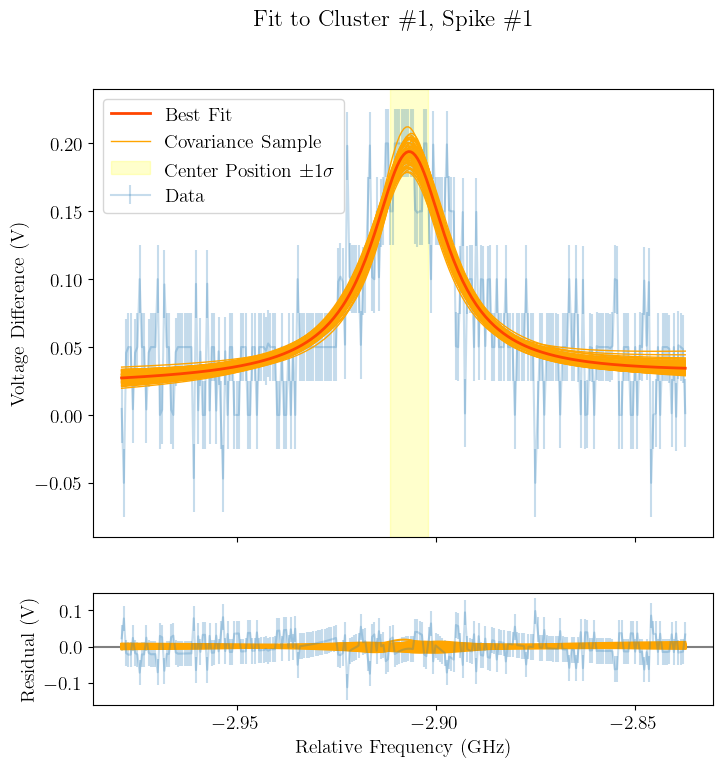

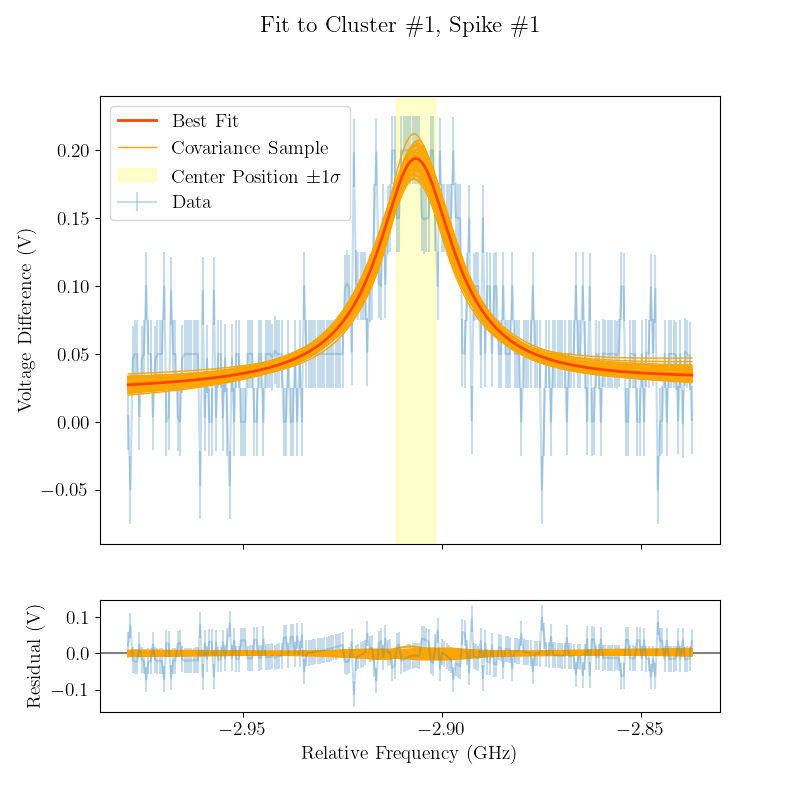

In [36]:
fit_spike(-.022, -.02, 0)

p0 = [-2.774798057640602, 0.01263668063863066, 0.5469130838582364, 0.0999999999999753, -8.893286449446092e-15]
fit params:
[-2.77597484e+00  1.31378321e-02  5.73295386e-01  2.21870469e-02
 -8.89328645e-15]
cov:
[[inf inf inf inf inf]
 [inf inf inf inf inf]
 [inf inf inf inf inf]
 [inf inf inf inf inf]
 [inf inf inf inf inf]]
local_uncertainty = 0.004359127314417458
this_spike = {'center_freq': -2.775974839657562, 'e_center_freq': 0.004359127314417458, 'amplitude': 0.5732953862723025, 'cluster_id': 0, 'red_chi2': 0.7838733709157464}
SPIKE NOT APPENDED, WE ALREADY GOT THIS ONE
len(spike_data) = 5
red_chi2 = 0.7839


/tmp/ipykernel_88722/3788268521.py:4: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, (fit_data_ax, fit_res_ax) = plt.subplots(2, 1, sharex=True, height_ratios=[4, 1], figsize=(8, 8))
/tmp/ipykernel_88722/3788268521.py:44: OptimizeWarning: Covariance of the parameters could not be estimated
  fit_params, cov = curve_fit(red_lorentzian, x, y, p0, np.sqrt(2)*0.025)


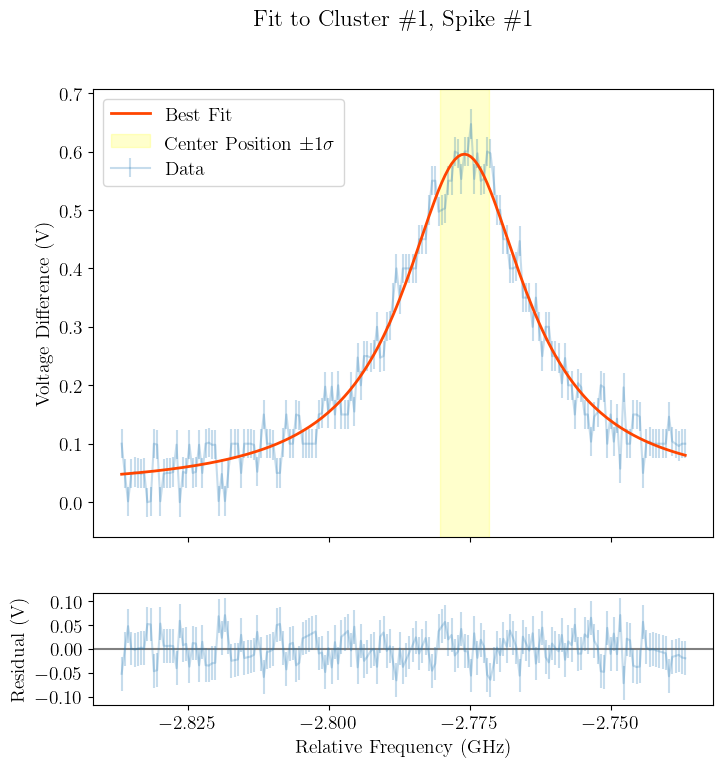

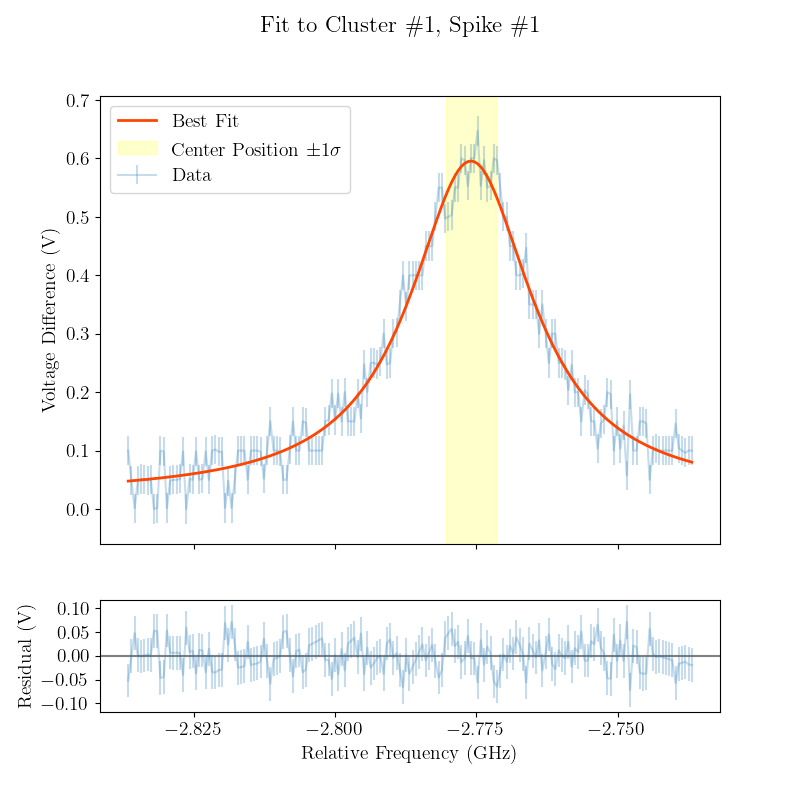

In [38]:
fit_spike(-.02, -.01860, 0)

p0 = [-2.701652719075426, 0.012126380957906857, 0.4169126097260147, 1.6474425463079485, 0.5823752808243221]
fit params:
[-2.70186019  0.01250416  0.41649598 -0.11646776 -0.05112265]
cov:
[[ 7.41141711e-08 -2.12730389e-08 -3.29448688e-07 -5.25867284e-05
  -1.96229175e-05]
 [-2.12730389e-08  4.03988661e-07  1.05237923e-06  6.78979903e-05
   2.68557565e-05]
 [-3.29448688e-07  1.05237923e-06  9.72781483e-05  1.07423027e-03
   4.16582228e-04]
 [-5.25867284e-05  6.78979903e-05  1.07423027e-03  1.54732599e-01
   5.77849719e-02]
 [-1.96229175e-05  2.68557565e-05  4.16582228e-04  5.77849719e-02
   2.15888112e-02]]
local_uncertainty = 0.004139777455469389
this_spike = {'center_freq': -2.7018601917902947, 'e_center_freq': 0.004139777455469389, 'amplitude': 0.4164959764909965, 'cluster_id': 0, 'red_chi2': 0.843663352496175}
len(spike_data) = 6
red_chi2 = 0.8437


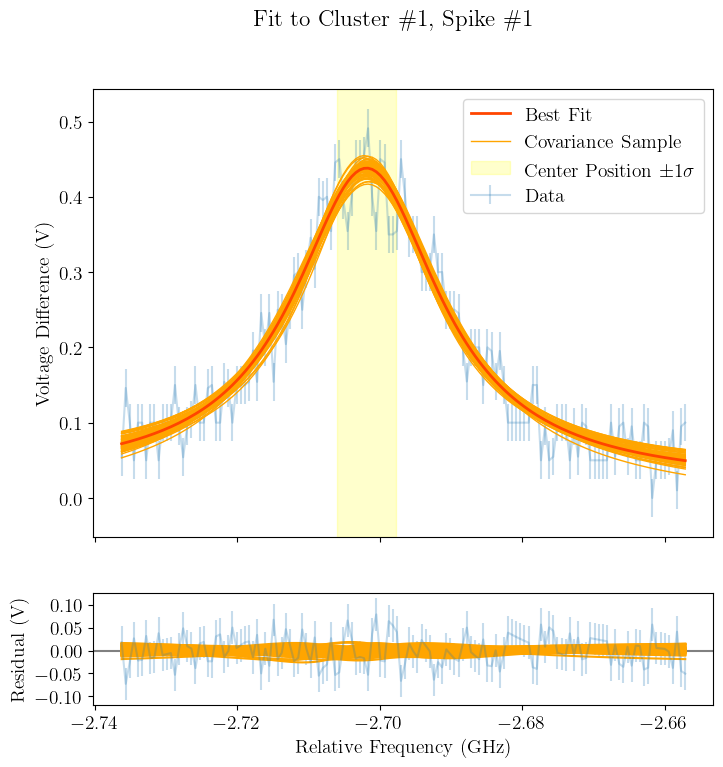

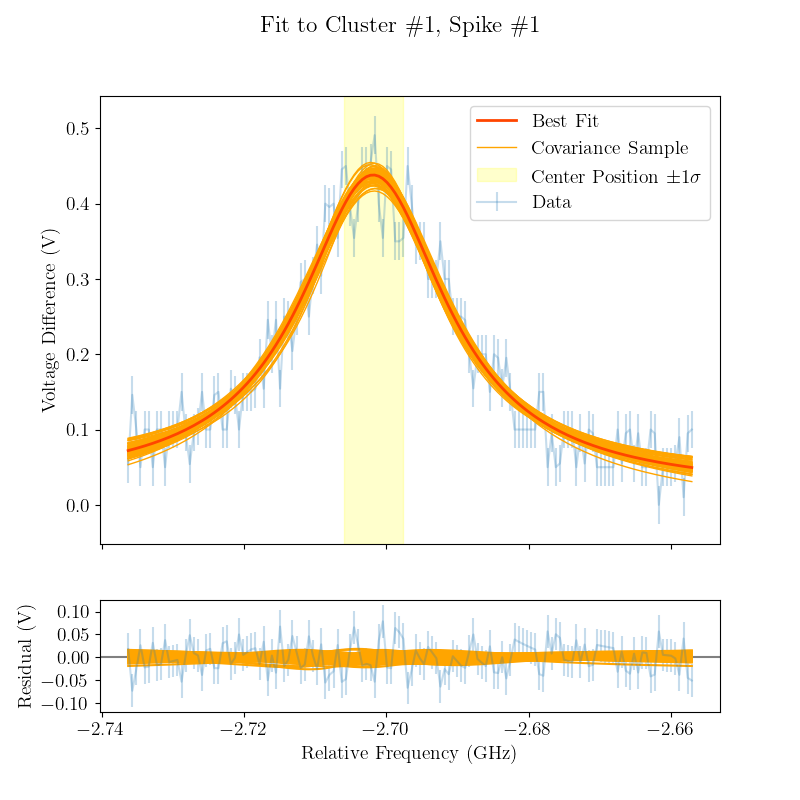

In [39]:
fit_spike(-.01860, -.01750, 0)

p0 = [-1.3027000675665572, 0.03155795121569227, 0.6027171863631313, 0.04999999999999982, 0.0]
fit params:
[-1.30178774  0.0416279   0.58392363 -0.11126663 -0.09258297]
cov:
[[ 1.13430037e-07  5.11322372e-09  1.30685492e-08 -5.04912761e-07
  -3.67068327e-07]
 [ 5.11322372e-09  3.56558261e-07 -1.33833980e-06 -1.32619018e-06
  -5.32923495e-07]
 [ 1.30685492e-08 -1.33833980e-06  2.19960703e-05 -2.84739968e-06
  -1.41929315e-06]
 [-5.04912761e-07 -1.32619018e-06 -2.84739968e-06  7.40838055e-05
   5.16867627e-05]
 [-3.67068327e-07 -5.32923495e-07 -1.41929315e-06  5.16867627e-05
   3.74458020e-05]]
local_uncertainty = 0.001897830686347413
this_spike = {'center_freq': -1.3017877373336788, 'e_center_freq': 0.001897830686347413, 'amplitude': 0.5839236328282191, 'cluster_id': 1, 'red_chi2': 0.9044216067381795}
len(spike_data) = 7
red_chi2 = 0.9044


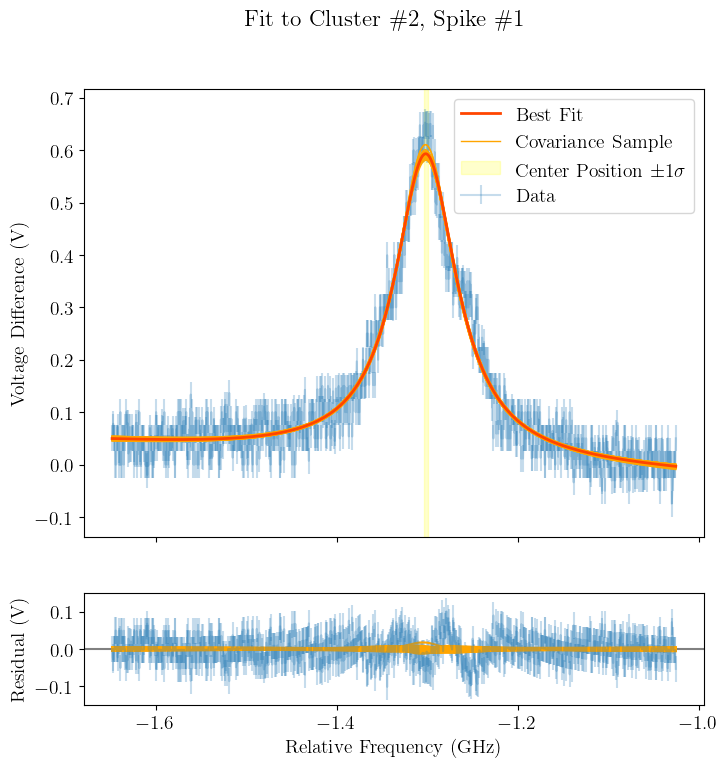

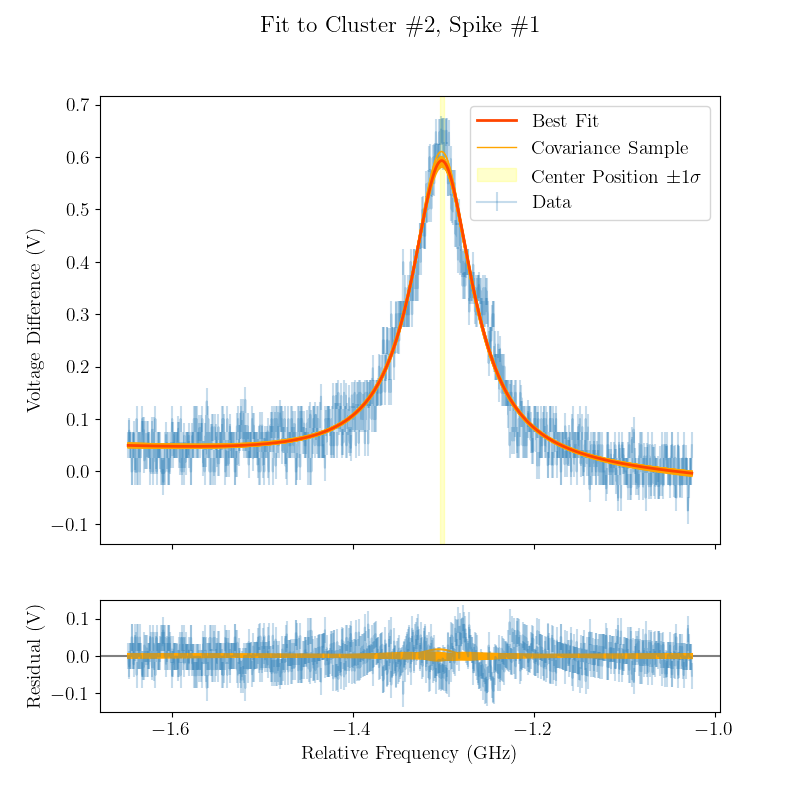

In [40]:
fit_spike(-.004, .004, 1)

p0 = [2.685194280659876, 0.012411306725073512, 0.3730177844899596, -2.374348358864797, 0.9129062250841796]
fit params:
[ 2.68391786  0.0125622   0.33504238 -1.07651319  0.42625008]
cov:
[[ 8.61047588e-08  3.06939659e-09  2.24253354e-08  1.30162238e-05
  -4.86365999e-06]
 [ 3.06939659e-09  3.24334192e-07 -1.41570740e-06  4.72267743e-06
  -2.36781385e-06]
 [ 2.24253354e-08 -1.41570740e-06  5.99234233e-05  3.91556781e-05
  -1.73402799e-05]
 [ 1.30162238e-05  4.72267743e-06  3.91556781e-05  2.44309153e-02
  -9.12552646e-03]
 [-4.86365999e-06 -2.36781385e-06 -1.73402799e-05 -9.12552646e-03
   3.41086525e-03]]
local_uncertainty = 0.004492449325696
this_spike = {'center_freq': 2.683917858391496, 'e_center_freq': 0.004492449325696, 'amplitude': 0.33504237640707146, 'cluster_id': 3, 'red_chi2': 0.6443184240242205}
len(spike_data) = 8
red_chi2 = 0.6443


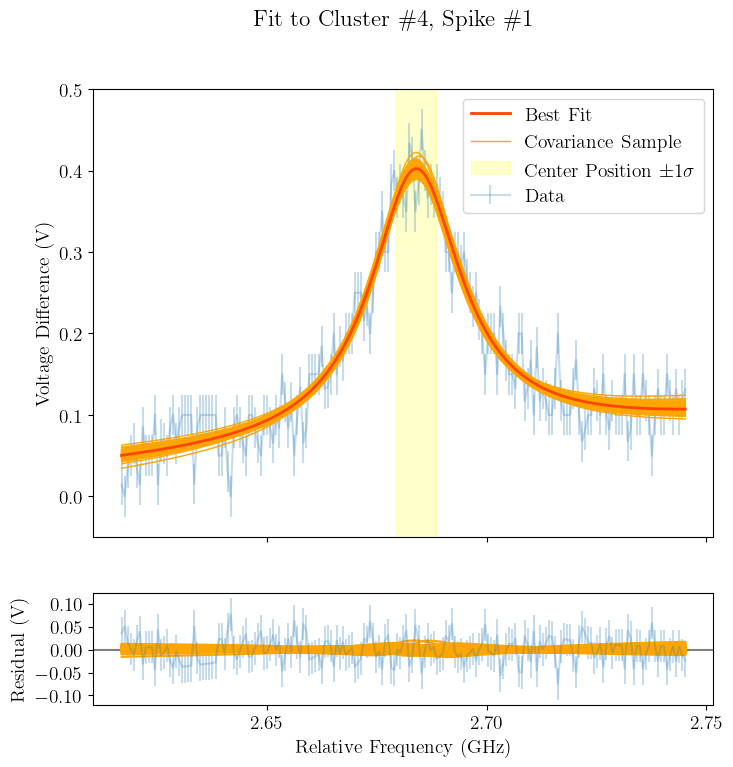

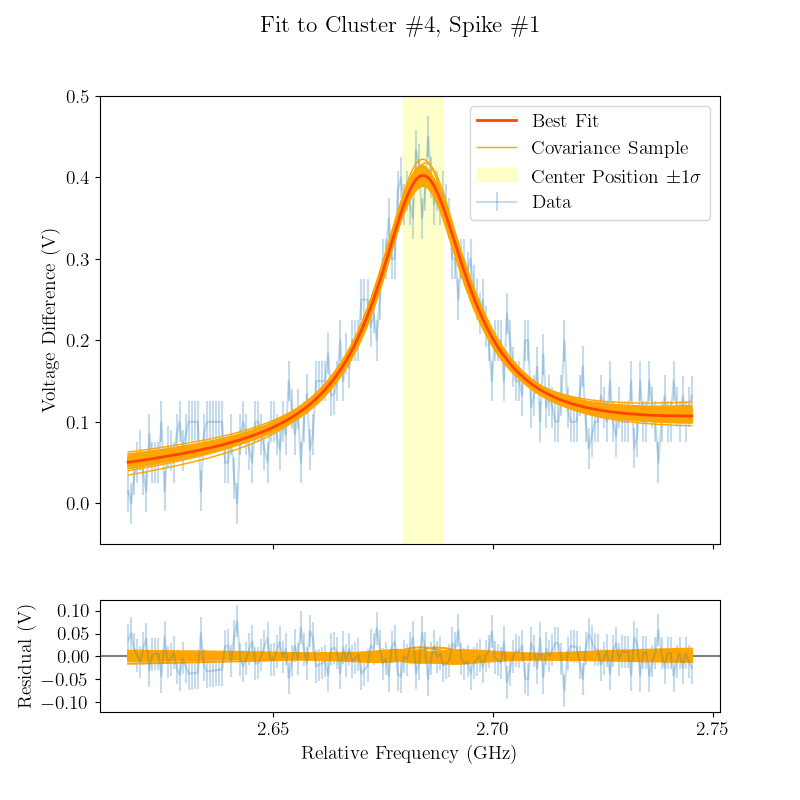

In [41]:
fit_spike(.0477, .0492, 3)

p0 = [2.8183378558318273, 0.018290028066698216, 0.9495634822534353, -3.9162456624115727, 1.4784182710870728]
fit params:
[ 2.81661319  0.01579477  1.0577524  -1.92509734  0.72582351]
cov:
[[ 1.51445845e-08  5.58696655e-09  1.35311403e-07  9.86520248e-06
  -3.57246683e-06]
 [ 5.58696655e-09  7.29895118e-08 -7.01409807e-08  2.65519399e-05
  -9.92235168e-06]
 [ 1.35311403e-07 -7.01409807e-08  7.48107916e-05  6.59748510e-04
  -2.43538762e-04]
 [ 9.86520248e-06  2.65519399e-05  6.59748510e-04  4.45731347e-02
  -1.61622326e-02]
 [-3.57246683e-06 -9.92235168e-06 -2.43538762e-04 -1.61622326e-02
   5.86334666e-03]]
local_uncertainty = 0.004951518412602064
this_spike = {'center_freq': 2.816613185177652, 'e_center_freq': 0.004951518412602064, 'amplitude': 1.0577523984811756, 'cluster_id': 3, 'red_chi2': 0.8330140295627808}
len(spike_data) = 9
red_chi2 = 0.833


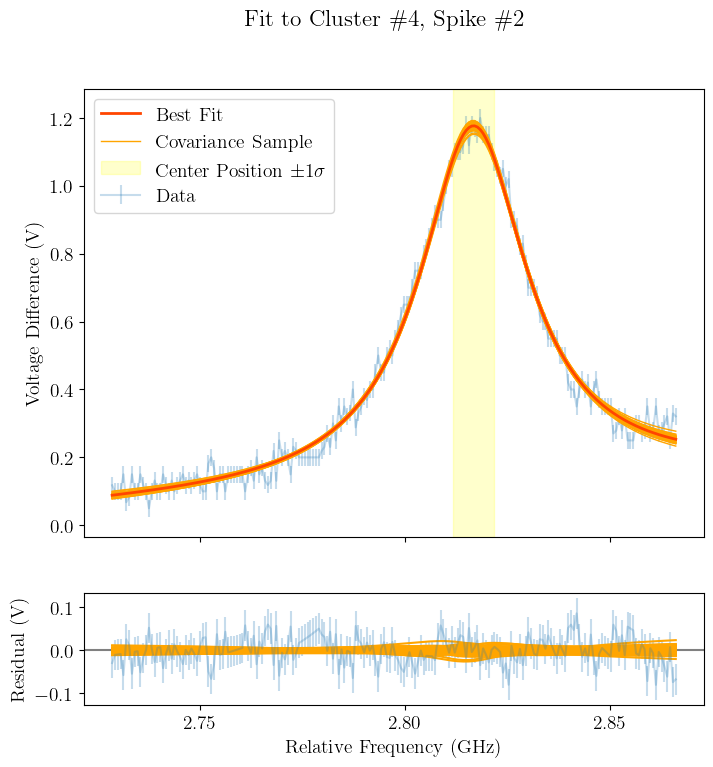

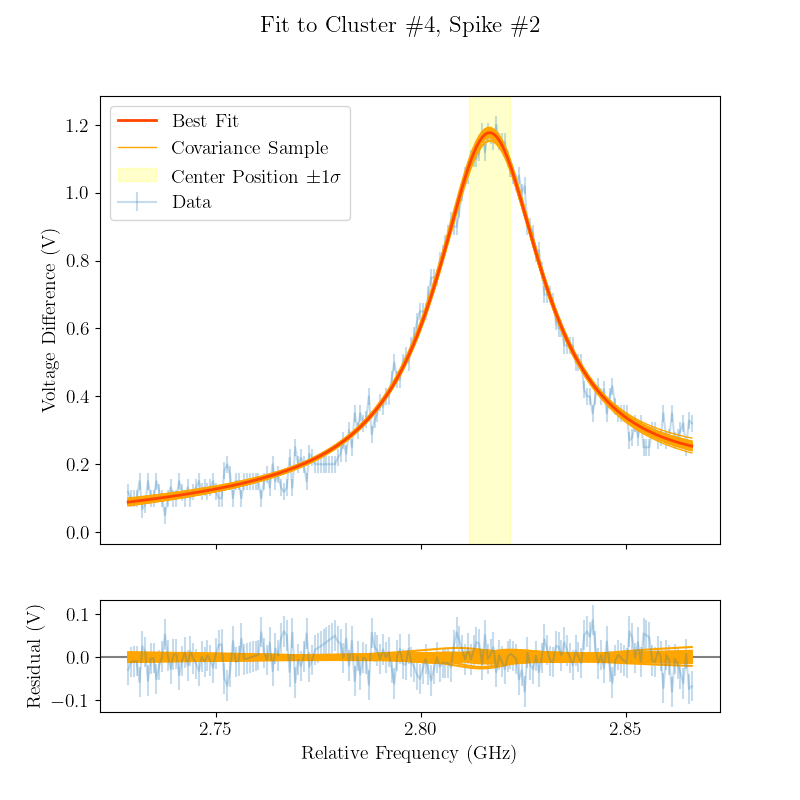

In [42]:
fit_spike(.04900, .0506, 3, spike_n=1)

p0 = [2.897732056137052, 0.017263742204319144, 0.6857336608588498, 2.925871226448115, -0.9259052476387608]
fit params:
[ 2.89509596  0.01389924  0.76428613  3.28522757 -1.0855305 ]
cov:
[[ 3.21153965e-08 -1.07001786e-08 -2.82577487e-07  4.01020473e-05
  -1.37255171e-05]
 [-1.07001786e-08  1.79865087e-07  9.78520548e-07 -6.26887797e-05
   2.04207171e-05]
 [-2.82577487e-07  9.78520548e-07  1.19312674e-04 -1.63578555e-03
   5.41542273e-04]
 [ 4.01020473e-05 -6.26887797e-05 -1.63578555e-03  1.96265294e-01
  -6.70583467e-02]
 [-1.37255171e-05  2.04207171e-05  5.41542273e-04 -6.70583467e-02
   2.29212860e-02]]
local_uncertainty = 0.005250701507142536
this_spike = {'center_freq': 2.8950959574299278, 'e_center_freq': 0.005250701507142536, 'amplitude': 0.7642861252807949, 'cluster_id': 3, 'red_chi2': 0.9062015600697692}
len(spike_data) = 10
red_chi2 = 0.9062


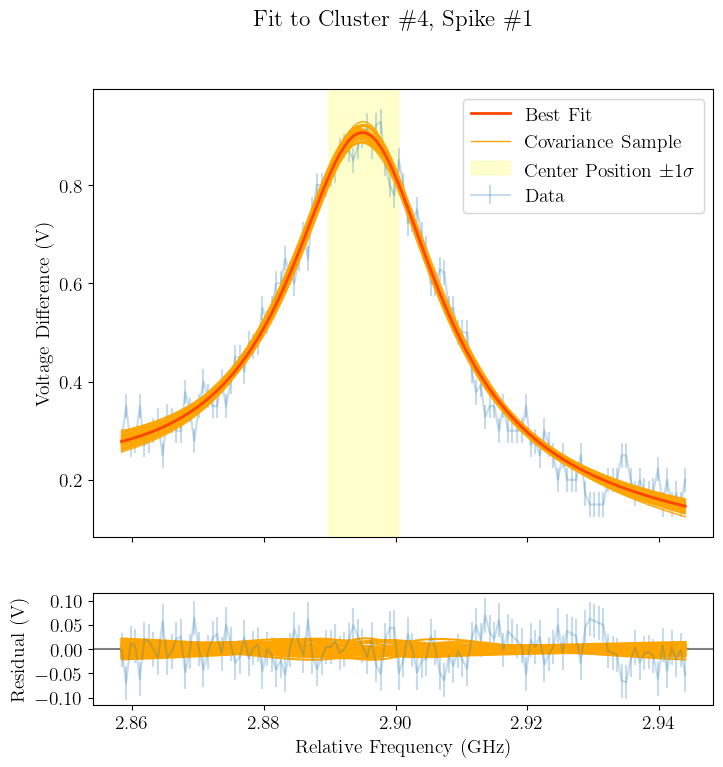

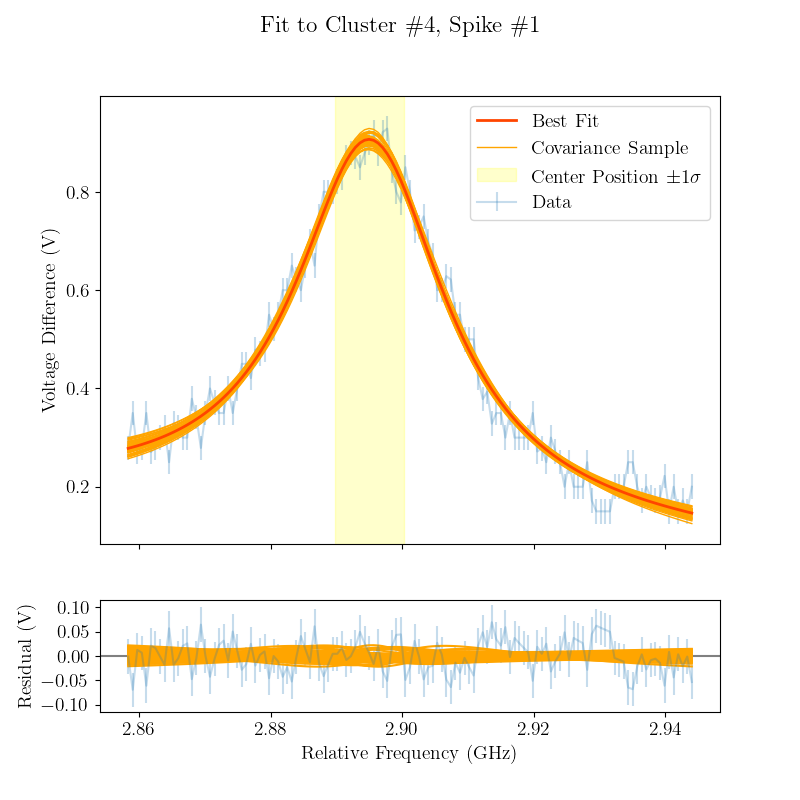

In [43]:
fit_spike(.0505, .0515, 3)

In [44]:
df = pd.DataFrame(spike_data).sort_values('center_freq').reset_index(drop=True)
df

,center_freq,e_center_freq,amplitude,cluster_id,red_chi2
0,-2.906682,0.004831,0.167539,0,0.846061
1,-2.775975,0.004359,0.573295,0,0.783873
2,-2.701860,0.004140,0.416496,0,0.843663
3,-1.301788,0.001898,0.583924,1,0.904422
4,1.562863,0.002277,0.288555,2,1.548990
5,1.624114,0.002277,1.103932,2,1.548990
6,1.655358,0.002277,1.371161,2,1.548990
7,2.683918,0.004492,0.335042,3,0.644318
8,2.816613,0.004952,1.057752,3,0.833014
9,2.895096,0.005251,0.764286,3,0.906202


In [ ]:
df.to_csv('sas_spike_data.csv', index=False)

In [ ]:
df.to_latex('sas_spike_data.tex')

In [ ]:
spacings_data = []
for i in range(1, len(df)):
    diff = df['center_freq'].iloc[i] - df['center_freq'].iloc[i - 1]
    if diff > 0.8: continue
    err = np.sqrt(df['e_center_freq'].iloc[i]**2 + df['e_center_freq'].iloc[i - 1]**2)
    spacings_data.append({
        "diff": diff,
        "err": err
    })

phys_spacing_data = []
for i in range(0, len(spacings_data), 2):
    phys_spacing_data.append({
        "spacing": spacings_data[i]['diff'] + spacings_data[i+1]['diff'],
        "error": np.sqrt(spacings_data[i]['err']**2 + spacings_data[i+1]['err']**2)
    })

phys_spacing = pd.DataFrame(phys_spacing_data)
phys_spacing['true'] = [
    .157 + .072,
    .121 + .063,
    .287 + .157
]
phys_spacing

In [ ]:
for s in phys_spacing['spacing']: print(f"{s:.4f}")

In [ ]:
for e in phys_spacing['error']: print(f"{e:.2g}")

In [ ]:
for se in ((phys_spacing['true'] - phys_spacing['spacing']) / phys_spacing['error']): print(f"{se:.2f}")

In [ ]:
for pe in (phys_spacing['true']/phys_spacing['spacing']) - 1: print(f'{pe:.0%}')

In [ ]:
for val in df['red_chi2']: print(f"{val:.4g}")